# Seminar 01 — Rebuilding a Deep Learning Pipeline

The lecture described deep learning as a chain of contracts. In this seminar we will:

1. build one small but correct baseline on `sklearn.datasets.load_digits`;
2. turn every lecture case into an executable micro-experiment;

## 0. Setup

In [1]:
import copy
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", DEVICE)

torch: 2.11.0+cpu | device: cpu


# Part I — One complete DL pipeline

## 1. Data contract: split first, fit transforms on train

`load_digits` contains 1,797 grayscale images of size $8\times8$ and 10 classes.

We keep a true test split untouched, and fit `StandardScaler` on **train only**.

In [2]:
digits = load_digits()
X_raw = digits.data.astype(np.float32)       # [N, 64]
y_raw = digits.target.astype(np.int64)       # [N]

all_idx = np.arange(len(X_raw))
train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.40, random_state=42, stratify=y_raw
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=y_raw[temp_idx]
)

In [3]:
scaler = StandardScaler().fit(X_raw[train_idx])
X_train = scaler.transform(X_raw[train_idx]).astype(np.float32)
X_val = scaler.transform(X_raw[val_idx]).astype(np.float32)
X_test = scaler.transform(X_raw[test_idx]).astype(np.float32)

y_train, y_val, y_test = y_raw[train_idx], y_raw[val_idx], y_raw[test_idx]

print("splits:", len(train_idx), len(val_idx), len(test_idx))
print("train feature mean after scaling:", float(X_train.mean()))

splits: 1078 359 360
train feature mean after scaling: -3.7598475444156065e-09


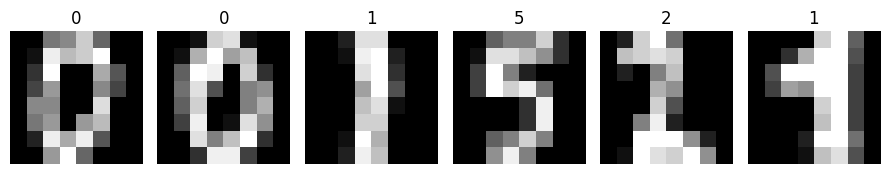

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, idx in zip(axes, train_idx[:6]):
    ax.imshow(X_raw[idx].reshape(8, 8), cmap="gray")
    ax.set_title(str(y_raw[idx]))
    ax.axis("off")
plt.tight_layout()

## 2. Tensor and batch contracts

Before looking at values, predict the `shape`, `dtype` and `device` of one batch.

The model will receive vectors `[B, 64]`; the head will return logits `[B, 10]`; targets are integer class indices `[B]`.

In [5]:
def as_dataset(X, y):
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

train_loader = DataLoader(as_dataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(as_dataset(X_val, y_val), batch_size=128, shuffle=False)
test_loader = DataLoader(as_dataset(X_test, y_test), batch_size=128, shuffle=False)

xb, yb = next(iter(train_loader))
print("x:", xb.shape, xb.dtype, xb.device)
print("y:", yb.shape, yb.dtype, yb.device)

x: torch.Size([64, 64]) torch.float32 cpu
y: torch.Size([64]) torch.int64 cpu


## 3. Autograd: values flow forward, sensitivities flow backward

For $z=\log(x^2+y)$ at $x=2, y=1$, predict $\partial z/\partial x$ and $\partial z/\partial y$.

Then verify them with autograd and observe that `.grad` is an accumulating buffer.

In [6]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)
z = torch.log(x**2 + y)
z.backward()

dx_manual = 2 * x.detach() / (x.detach()**2 + y.detach())
dy_manual = 1 / (x.detach()**2 + y.detach())
print("autograd:", x.grad.item(), y.grad.item())
print("manual:  ", dx_manual.item(), dy_manual.item())

autograd: 0.800000011920929 0.20000000298023224
manual:   0.800000011920929 0.20000000298023224


In [7]:
# A new graph adds into the same .grad buffers.
z2 = torch.log(x**2 + y)
z2.backward()
print("after a second backward:", x.grad.item(), y.grad.item())

x.grad.zero_()
y.grad.zero_()
print("after zeroing:", x.grad.item(), y.grad.item())

after a second backward: 1.600000023841858 0.4000000059604645
after zeroing: 0.0 0.0


## 4. Model, head and objective

The backbone builds a representation; the head converts it to **raw logits**.

`CrossEntropyLoss` expects logits `[B, C]` and class indices `[B]` — no `Softmax` inside `forward()`.

In [8]:
class DigitMLP(nn.Module):
    def __init__(self, hidden=64, representation=32, classes=10):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(64, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, representation),
            nn.ReLU(),
        )
        self.head = nn.Linear(representation, classes)

    def forward(self, x):
        features = self.backbone(x)
        logits = self.head(features)
        return logits

In [9]:
model = DigitMLP().to(DEVICE)
logits = model(xb.to(DEVICE))
print("logits:", logits.shape, logits.dtype)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss()
loss = criterion(logits, yb.to(DEVICE))
print("scalar loss:", loss.item())

logits: torch.Size([64, 10]) torch.float32
trainable parameters: 6698
scalar loss: 2.327265501022339


## 5. A correct training step and a comparable evaluator

The two functions deliberately keep **mode**, **gradient context** and **aggregation** explicit.

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    loss_sum, correct, count = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        batch_size = y.numel()
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=-1) == y).sum().item()
        count += batch_size

    return {"loss": loss_sum / count, "accuracy": correct / count}


def evaluate(model, loader, criterion, device=DEVICE):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0

    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            batch_size = y.numel()
            loss_sum += loss.item() * batch_size
            correct += (logits.argmax(dim=-1) == y).sum().item()
            count += batch_size

    return {"loss": loss_sum / count, "accuracy": correct / count}

In [11]:
seed_everything(42)
model = DigitMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

In [12]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_accuracy = -float("inf")
best_epoch = None
best_state = None
for epoch in range(12):

    train_stats = train_one_epoch(model, train_loader, optimizer, criterion)

    val_stats = evaluate(model, val_loader, criterion)

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_acc"].append(train_stats["accuracy"])
    history["val_acc"].append(val_stats["accuracy"])

    if val_stats["accuracy"] > best_val_accuracy:
        best_val_accuracy = val_stats["accuracy"]
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())

best validation epoch: 5
selected validation accuracy: 0.972
test accuracy (report once): 0.947


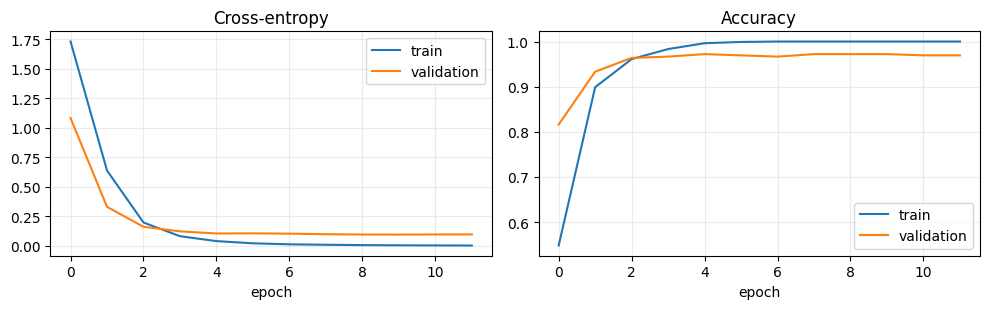

In [13]:
model.load_state_dict(best_state)
test_stats = evaluate(model, test_loader, criterion)
print(f"best validation epoch: {best_epoch}")
print(f"selected validation accuracy: {best_val_accuracy:.3f}")
print(f"test accuracy (report once): {test_stats['accuracy']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_title("Cross-entropy")
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_title("Accuracy")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()

### Checkpoint contract

`state_dict` stores parameters and persistent buffers.

A newly constructed model with the same architecture should reproduce the selected model in `eval()` mode after loading it.

In [14]:
checkpoint_c1 = copy.deepcopy(model.state_dict())
restored_model = DigitMLP().to(DEVICE)
restored_model.load_state_dict(checkpoint_c1)

model.eval()
restored_model.eval()
with torch.inference_mode():
    reference_logits = model(xb.to(DEVICE))
    restored_logits = restored_model(xb.to(DEVICE))

print("max checkpoint reconstruction error:",
      (reference_logits - restored_logits).abs().max().item())

max checkpoint reconstruction error: 0.0


## 6. Fine-tuning contract: a linear probe

Reuse the learned representation for a new task: predict digit parity.

Replace the head, freeze the backbone, build a new optimizer from the intended subset, and verify that backbone values do not move.

In [15]:
parity_train = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train % 2)),
    batch_size=64, shuffle=True,
)
parity_val = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val % 2)),
    batch_size=128, shuffle=False,
)

In [16]:
probe = copy.deepcopy(model)
probe.head = nn.Linear(32, 2).to(DEVICE)
for parameter in probe.backbone.parameters():
    parameter.requires_grad_(False)

probe_optimizer = torch.optim.AdamW(
    [p for p in probe.parameters() if p.requires_grad], lr=5e-3
)

In [17]:
backbone_before = [p.detach().clone() for p in probe.backbone.parameters()]
for _ in range(5):
    train_one_epoch(probe, parity_train, probe_optimizer, criterion)

probe_stats = evaluate(probe, parity_val, criterion)
backbone_unchanged = all(
    torch.equal(before, after.detach())
    for before, after in zip(backbone_before, probe.backbone.parameters())
)

print("trainable tensors:", [name for name, p in probe.named_parameters() if p.requires_grad])
print("backbone unchanged:", backbone_unchanged)
print("parity validation accuracy:", round(probe_stats["accuracy"], 3))

trainable tensors: ['head.weight', 'head.bias']
backbone unchanged: True
parity validation accuracy: 0.969


# Part II — Thirteen executable lecture cases

Each case is a tiny unit test of one pipeline boundary. Use the same rhythm every time:

1. **Predict** the output before execution.
2. **Locate** the violated contract.
3. **Repair** one line or one state transition.
4. **State an invariant** that could become an assertion or test.

## Case 01 — Data · splits · learned preprocessing

**Given:** train features have mean near 0; validation features are shifted by +5.  
**Question:** why does fitting normalization on the concatenated data leak validation information?  
**Predict:** compare the learned center for train-only fit and full-data fit.

In [18]:
seed_everything(1)
x_train_c1 = torch.randn(400, 1)
x_val_c1 = torch.randn(100, 1) + 5.0

train_center = x_train_c1.mean(dim=0)
leaky_center = torch.cat([x_train_c1, x_val_c1]).mean(dim=0)

clean_train_mean = (x_train_c1 - train_center).mean()
leaky_train_mean = (x_train_c1 - leaky_center).mean()

print(f"train-only center: {train_center.item():+.3f}")
print(f"full-data center:  {leaky_center.item():+.3f}")
print(f"train mean after clean transform: {clean_train_mean.item():+.3f}")
print(f"train mean after leaky transform: {leaky_train_mean.item():+.3f}")

train-only center: +0.024
full-data center:  +1.006
train mean after clean transform: -0.000
train mean after leaky transform: -0.982


## Case 02 — Tensor semantics · broadcasting

**Given:** predictions have shape `[B, 1]`; targets have shape `[B]`.  
**Question:** what error tensor does broadcasting create, and why can the scalar loss be wrong without an exception?

In [19]:
pred_c2 = torch.tensor([[0.0], [1.0], [2.0]])   # [B, 1]
target_c2 = torch.tensor([0.0, 1.0, 2.0])       # [B]

pairwise_errors = (pred_c2 - target_c2) ** 2
bad_loss = pairwise_errors.mean()
good_loss = ((pred_c2.squeeze(-1) - target_c2) ** 2).mean()

print("broadcasted error shape:", tuple(pairwise_errors.shape))
print(pairwise_errors)
print(f"bad loss: {bad_loss.item()} | aligned loss: {good_loss.item()}")

broadcasted error shape: (3, 3)
tensor([[0., 1., 4.],
        [1., 0., 1.],
        [4., 1., 0.]])
bad loss: 1.3333333730697632 | aligned loss: 0.0


## Case 03 — Batching · padding · masks

**Given:** variable-length sequences are padded, then mean-pooled.  
**Question:** why can a sample representation depend on the longest neighbor in its batch?

In [20]:
sequences_c3 = [torch.tensor([2.0, 4.0]), torch.tensor([1.0, 3.0, 5.0, 7.0])]
lengths_c3 = torch.tensor([len(s) for s in sequences_c3])
padded_c3 = pad_sequence(sequences_c3, batch_first=True, padding_value=0.0)
mask_c3 = torch.arange(padded_c3.shape[1])[None, :] < lengths_c3[:, None]

naive_mean = padded_c3.mean(dim=1)
masked_mean = (padded_c3 * mask_c3).sum(dim=1) / mask_c3.sum(dim=1)

print("padded:\n", padded_c3)
print("naive mean:", naive_mean.tolist())
print("masked mean:", masked_mean.tolist())

padded:
 tensor([[2., 4., 0., 0.],
        [1., 3., 5., 7.]])
naive mean: [1.5, 4.0]
masked mean: [3.0, 4.0]


## Case 04 — Model · nonlinearity · depth

**Given:** two affine layers are stacked without an activation.  
**Question:** did the extra depth add nonlinear expressive power?

In [21]:
seed_everything(4)
layer1_c4 = nn.Linear(3, 5)
layer2_c4 = nn.Linear(5, 2)
x_c4 = torch.randn(7, 3)

stacked_affine = layer2_c4(layer1_c4(x_c4))
combined_weight = layer2_c4.weight @ layer1_c4.weight
combined_bias = layer2_c4.weight @ layer1_c4.bias + layer2_c4.bias
single_affine = F.linear(x_c4, combined_weight, combined_bias)

with_nonlinearity = layer2_c4(F.relu(layer1_c4(x_c4)))

print("max |two affine layers - one affine layer|:", (stacked_affine - single_affine).abs().max().item())
print("max |nonlinear stack - affine collapse|:", (with_nonlinearity - single_affine).abs().max().item())

max |two affine layers - one affine layer|: 1.1920928955078125e-07
max |nonlinear stack - affine collapse|: 0.8689466118812561


## Case 05 — Head · target · loss contract

**Given:** a single-label three-class problem has three logits per example.  
**Question:** why are one-hot targets with independent BCE a different task from multiclass cross-entropy?

In [22]:
logits_c5 = torch.tensor([[2.0, 0.5, -1.0], [-0.5, 1.0, 0.0]])
class_index_c5 = torch.tensor([0, 1])
one_hot_c5 = F.one_hot(class_index_c5, num_classes=3).float()

multiclass_loss = F.cross_entropy(logits_c5, class_index_c5)
independent_bce = F.binary_cross_entropy_with_logits(logits_c5, one_hot_c5)
softmax_prob = logits_c5.softmax(dim=-1)
sigmoid_prob = logits_c5.sigmoid()

print("CE:", round(multiclass_loss.item(), 4), "| BCE:", round(independent_bce.item(), 4))
print("softmax row sums:", softmax_prob.sum(dim=-1).tolist())
print("sigmoid row sums:", sigmoid_prob.sum(dim=-1).tolist())

CE: 0.3528 | BCE: 0.4825
softmax row sums: [1.0, 0.9999999403953552]
sigmoid row sums: [1.7721977233886719, 1.608599305152893]


## Case 06 — Numerical stability · logits to loss

**Given:** extreme logits are converted to `softmax`, then `log`.  
**Question:** why can mathematically equivalent code produce `-inf`, while a fused loss stays finite?

In [23]:
logits_c6 = torch.tensor([[1000.0, -1000.0]])
target_c6 = torch.tensor([1])

unstable_log_prob = logits_c6.softmax(dim=-1).log()
stable_log_prob = logits_c6.log_softmax(dim=-1)
stable_loss = F.cross_entropy(logits_c6, target_c6)

print("log(softmax):", unstable_log_prob.tolist())
print("log_softmax: ", stable_log_prob.tolist())
print("cross-entropy:", stable_loss.item(), "| finite:", torch.isfinite(stable_loss).item())

log(softmax): [[0.0, -inf]]
log_softmax:  [[0.0, -2000.0]]
cross-entropy: 2000.0 | finite: True


## Case 07 — Reduction · gradient scale

**Given:** an identical error term is repeated a different number of times.  
**Question:** when should the gradient grow with the number of terms, and when should it remain invariant?

In [24]:
def gradient_for_repeated_terms(n, reduction):
    theta = torch.tensor(1.0, requires_grad=True)
    losses = (theta - torch.zeros(n)) ** 2
    scalar = losses.sum() if reduction == "sum" else losses.mean()
    scalar.backward()
    return theta.grad.item()

for n in [2, 8]:
    print(f"n={n}: sum grad={gradient_for_repeated_terms(n, 'sum'):.1f}, "
          f"mean grad={gradient_for_repeated_terms(n, 'mean'):.1f}")

n=2: sum grad=4.0, mean grad=2.0
n=8: sum grad=16.0, mean grad=2.0


## Case 08 — Training step · gradient accumulation

**Given:** two microbatches should simulate one larger batch.  
**Question:** why must parameters remain fixed until all microbatch gradients have been accumulated?

In [29]:
microbatches_c8 = [
    (torch.tensor([[1.0]]), torch.tensor([[1.0]])),
    (torch.tensor([[2.0]]), torch.tensor([[2.0]])),
]

x_full = torch.cat([x for x, _ in microbatches_c8])
y_full = torch.cat([y for _, y in microbatches_c8])

In [30]:
def fresh_scalar_model():
    m = nn.Linear(1, 1, bias=False)
    nn.init.zeros_(m.weight)
    return m

In [31]:
# Reference: one physical batch.
full_model = fresh_scalar_model()
full_opt = torch.optim.SGD(full_model.parameters(), lr=0.1)

full_opt.zero_grad()
F.mse_loss(full_model(x_full), y_full).backward()
full_opt.step()
print("full batch weight:", full_model.weight.item())

full batch weight: 0.5


In [32]:
# Broken: step after every backward while stale gradients remain.
bad_model = fresh_scalar_model()
bad_opt = torch.optim.SGD(bad_model.parameters(), lr=0.1)
bad_opt.zero_grad()
for x_mb, y_mb in microbatches_c8:
    F.mse_loss(bad_model(x_mb), y_mb).backward()
    bad_opt.step()
print("broken schedule:  ", bad_model.weight.item())

broken schedule:   1.0399999618530273


In [33]:
# Correct accumulation: one zero, K normalized backwards, one step.
good_model = fresh_scalar_model()
good_opt = torch.optim.SGD(good_model.parameters(), lr=0.1)

good_opt.zero_grad()
for x_mb, y_mb in microbatches_c8:
    (F.mse_loss(good_model(x_mb), y_mb) / len(microbatches_c8)).backward()
good_opt.step()
print("good accumulation:", good_model.weight.item())

good accumulation: 0.5


## Case 09 — Backpropagation · graph paths

**Given:** an auxiliary head receives `features.detach()`.  
**Question:** which parameters can this auxiliary loss reach?

In [34]:
seed_everything(9)
backbone_c9 = nn.Linear(2, 3)
aux_head_c9 = nn.Linear(3, 1)
x_c9 = torch.randn(4, 2)

aux_loss_detached = aux_head_c9(backbone_c9(x_c9).detach()).sum()
aux_loss_detached.backward()
print("detached — backbone grad is None:", backbone_c9.weight.grad is None)
print("detached — head grad norm:", aux_head_c9.weight.grad.norm().item())

backbone_c9.zero_grad()
aux_head_c9.zero_grad()
aux_loss_connected = aux_head_c9(backbone_c9(x_c9)).sum()
aux_loss_connected.backward()
print("connected — backbone grad norm:", backbone_c9.weight.grad.norm().item())

detached — backbone grad is None: True
detached — head grad norm: 5.114203453063965
connected — backbone grad norm: 2.5906708240509033


## Case 10 — Optimizer membership · freezing

**Given:** two parameters both have gradients, but only one belongs to the optimizer.  
**Question:** which parameter values will `step()` change?

In [35]:
p_c10 = nn.Parameter(torch.tensor(2.0))
q_c10 = nn.Parameter(torch.tensor(2.0))
optimizer_c10 = torch.optim.SGD([p_c10], lr=0.1)

p_before, q_before = p_c10.item(), q_c10.item()
loss_c10 = p_c10**2 + q_c10**2
loss_c10.backward()
optimizer_c10.step()

print("p grad / before / after:", p_c10.grad.item(), p_before, p_c10.item())
print("q grad / before / after:", q_c10.grad.item(), q_before, q_c10.item())
assert q_c10.grad is not None and q_c10.item() == q_before

p grad / before / after: 4.0 2.0 1.600000023841858
q grad / before / after: 4.0 2.0 2.0


## Case 11 — Physical batch · effective batch · BatchNorm

**Given:** gradient accumulation emulates a larger update, but BatchNorm still sees each physical microbatch.  
**Question:** can the same sample receive different normalized outputs because its neighbors changed?

In [37]:
bn_c11 = nn.BatchNorm1d(1)
batch_a_c11 = torch.tensor([[1.0], [0.0], [0.0], [0.0]])
batch_b_c11 = torch.tensor([[1.0], [10.0], [10.0], [10.0]])

bn_c11.train()
out_a_train = bn_c11(batch_a_c11)[0].item()
out_b_train = bn_c11(batch_b_c11)[0].item()
print("train mode, same sample in two batches:", round(out_a_train, 3), round(out_b_train, 3))

bn_c11.eval()
out_a_eval = bn_c11(batch_a_c11)[0].item()
out_b_eval = bn_c11(batch_b_c11)[0].item()
print("eval mode, same sample in two batches: ", round(out_a_eval, 3), round(out_b_eval, 3))

train mode, same sample in two batches: 1.732 -1.732
eval mode, same sample in two batches:  0.12 0.12


## Case 12 — Stabilization ≠ regularization

**Given:** one run has an exploding update; another overfits.  
**Question:** why are gradient clipping and weight decay not interchangeable fixes?

In [ ]:
# Stabilization: cap a rare, extremely large gradient.
p_clip_c12 = nn.Parameter(torch.tensor(10.0))
(p_clip_c12**4).backward()
grad_before = p_clip_c12.grad.abs().item()
nn.utils.clip_grad_norm_([p_clip_c12], max_norm=1.0)
grad_after = p_clip_c12.grad.abs().item()
print("gradient norm before / after clipping:", grad_before, grad_after)

# Regularization/control: weight decay moves a parameter even with zero data gradient.
p_decay_c12 = nn.Parameter(torch.tensor(1.0))
opt_decay_c12 = torch.optim.SGD([p_decay_c12], lr=0.1, weight_decay=0.1)
p_decay_c12.grad = torch.zeros_like(p_decay_c12)
opt_decay_c12.step()
print("parameter after a pure weight-decay step:", p_decay_c12.item())

gradient norm before / after clipping: 4000.0 1.0
parameter after a pure weight-decay step: 0.9900000095367432


## Case 13 — Evaluation · inference · fine-tuning controls

**Given:** a backbone is frozen for a linear probe, but the whole model remains in training mode.  
**Question:** why does “frozen weights” not imply “frozen behavior,” and which four controls are independent?

In [38]:
class StatefulProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(4, 4),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.Dropout(0.5),
        )
        self.head = nn.Linear(4, 2)

    def forward(self, x):
        return self.head(self.backbone(x))

In [39]:
seed_everything(13)
stateful_c13 = StatefulProbe()
for p in stateful_c13.backbone.parameters():
    p.requires_grad_(False)
optimizer_c13 = torch.optim.SGD(stateful_c13.head.parameters(), lr=0.1)

x_c13 = torch.randn(8, 4)
y_c13 = torch.randint(0, 2, (8,))

In [40]:
bn_running_mean_before = stateful_c13.backbone[1].running_mean.clone()
stateful_c13.train()
train_out_1 = stateful_c13(x_c13)
train_out_2 = stateful_c13(x_c13)
bn_running_mean_after = stateful_c13.backbone[1].running_mean.clone()

print("train outputs equal:", torch.allclose(train_out_1, train_out_2))
print("BatchNorm running state changed in train mode:",
      not torch.equal(bn_running_mean_before, bn_running_mean_after))

train outputs equal: False
BatchNorm running state changed in train mode: True


In [41]:
stateful_c13.eval()
eval_out_1 = stateful_c13(x_c13)
eval_out_2 = stateful_c13(x_c13)
with torch.no_grad():
    inference_out = stateful_c13(x_c13)
print("eval outputs equal: ", torch.allclose(eval_out_1, eval_out_2))
print("no_grad output requires_grad:", inference_out.requires_grad)

eval outputs equal:  True
no_grad output requires_grad: False


In [42]:
# eval() does not disable gradients or optimizer updates.
optimizer_c13.zero_grad()
eval_loss = F.cross_entropy(stateful_c13(x_c13), y_c13)
eval_loss.backward()

print("backbone grad exists:", any(p.grad is not None for p in stateful_c13.backbone.parameters()))
print("head grad exists:", any(p.grad is not None for p in stateful_c13.head.parameters()))

backbone grad exists: False
head grad exists: True
